In [1]:
from experiment import Experiment

In [2]:
experiment = Experiment(f'snow_cover_base', 'last')
experiment.run_full_test('test', 'snow_cover')

In [2]:
experiment = Experiment(f'snow_cover_v1', 'last')
experiment.run_full_test('test', 'snow_cover')

2024-09-30 00:00:00
2024-10-31 00:00:00
2024-11-30 00:00:00
2024-12-31 00:00:00
2025-01-31 00:00:00
2025-02-28 00:00:00
2025-03-31 00:00:00
2025-04-30 00:00:00
2025-05-31 00:00:00
2025-06-30 00:00:00
2025-07-31 00:00:00
2025-08-31 00:00:00
2025-09-30 00:00:00
2025-10-31 00:00:00
2025-11-30 00:00:00
2025-12-31 00:00:00
2026-01-31 00:00:00
2026-02-28 00:00:00
2026-03-31 00:00:00
2026-04-30 00:00:00
2026-05-31 00:00:00


test:   0%|          | 0/1708 [00:00<?, ?batch/s]

save:   0%|          | 0/21 [00:00<?, ?file/s]

In [28]:
from matplotlib import pyplot as plt
import xarray as xr

path = '../experiments/snow_cover_v1/result'
ds = xr.open_dataset(f'{path}/202503.nc', engine='h5netcdf')

path = '../experiments/snow_cover_base/result'
ds2 = xr.open_dataset(f'{path}/202503.nc', engine='h5netcdf')

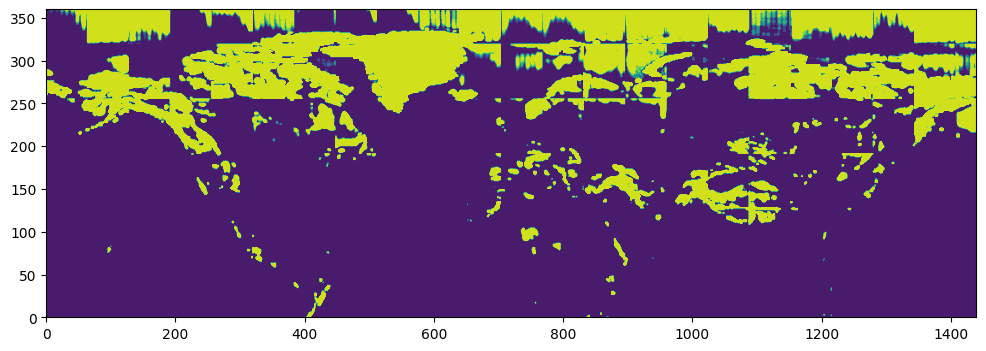

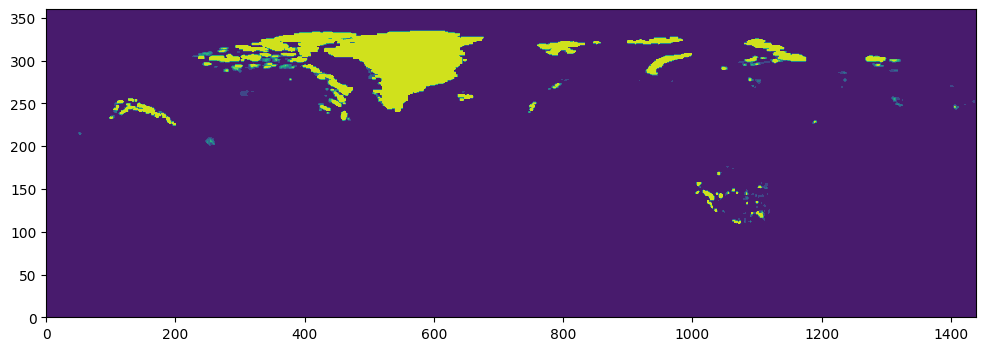

In [5]:
plt.figure(figsize=(12, 4))
plt.contourf(ds.output.values[-1, :, :])
plt.show()
plt.figure(figsize=(12, 4))
plt.contourf(ds.target.values[-1, :, :])
plt.show()

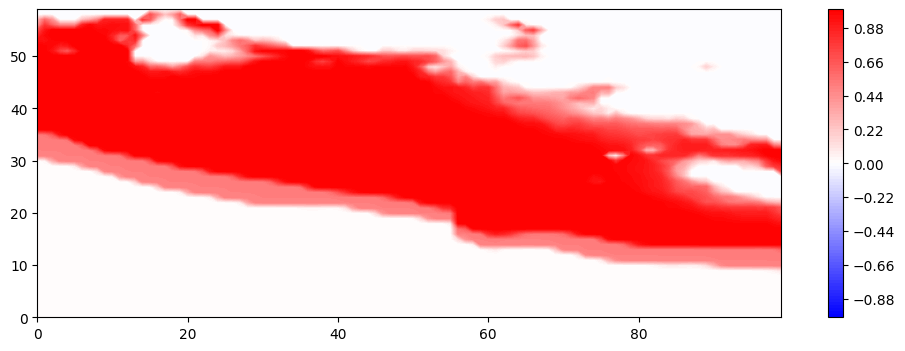

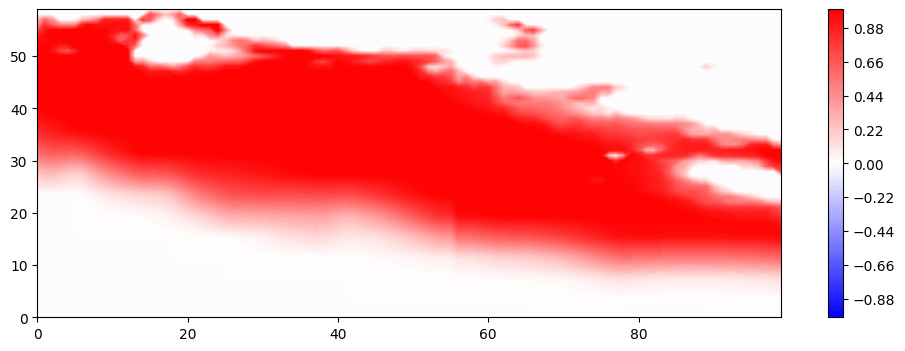

-0.025901947


In [32]:
import numpy as np

ds.lat.values[190:250]
ds.lon.values[840:940]-180

y1 = np.mean(ds.output.values[:2, 190:250, 840:940] - ds.target.values[:2, 190:250, 840:940], axis=0)
y2 = np.mean(ds2.output.values[:2, 190:250, 840:940] - ds2.target.values[:2, 190:250, 840:940], axis=0)

plt.figure(figsize=(12, 4))
plt.contourf(y1, np.linspace(-1, 1, 101), cmap='bwr')
plt.colorbar()
plt.show()

plt.figure(figsize=(12, 4))
plt.contourf(y2, np.linspace(-1, 1, 101), cmap='bwr')
plt.colorbar()
plt.show()

print(np.mean(np.abs(y1) - np.abs(y2)))